In [39]:
import pandas as pd
from sdv.single_table import CTGANSynthesizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
real_train = pd.read_csv('../data/processed/v4/real_train_data.csv')
real_test = pd.read_csv('../data/processed/v4/real_test_data.csv')

In [3]:
target = 'Credit_Score'

# Real data credit model

In [4]:
real_train['Outstanding_Debt'] = real_train['Outstanding_Debt'] / 1000 # Scale to thousands
real_test['Outstanding_Debt'] = real_test['Outstanding_Debt'] / 1000 # Scale to thousands

In [5]:
real_train = real_train[[
    'Num_Credit_Card',
    'Changed_Credit_Limit',
    'Delay_from_due_date',
    'Interest_Rate',
    'Credit_Mix',
    'Outstanding_Debt',
    target
]]

real_train = pd.get_dummies(real_train, columns=['Credit_Mix'], drop_first=True)
real_test = pd.get_dummies(real_test, columns=['Credit_Mix'], drop_first=True)

In [6]:
X_real_train = real_train.drop(columns=[target])
y_real_train = real_train[target]

X_real_test = real_test[X_real_train.columns] 
y_real_test = real_test[target]

In [7]:
real_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
).fit(X_real_train, y_real_train)

In [21]:
coefficients = real_model.coef_[0]
coef_dict = dict(zip(X_real_train.columns, coefficients))

print("Feature Coefficients:")
for feature, coef in coef_dict.items():
    print(f"{feature}: {coef:.4f}")

Feature Coefficients:
Num_Credit_Card: -0.1558
Changed_Credit_Limit: 0.0075
Delay_from_due_date: -0.0179
Interest_Rate: -0.0324
Outstanding_Debt: -0.0112
Credit_Mix_Good: 1.4642
Credit_Mix_Standard: 0.2479


In [24]:
def real_data_credit_score(
        coef_dict,
        num_credit_card, changed_credit_limit, delay_from_due_date, interest_rate, 
        outstanding_debt, credit_mix_good, credit_mix_standard
):
    score = (
        coef_dict['Num_Credit_Card'] * num_credit_card +
        coef_dict['Changed_Credit_Limit'] * changed_credit_limit +
        coef_dict['Delay_from_due_date'] * delay_from_due_date +
        coef_dict['Interest_Rate'] * interest_rate +
        coef_dict['Outstanding_Debt'] * outstanding_debt +
        coef_dict['Credit_Mix_Good'] * credit_mix_good +
        coef_dict['Credit_Mix_Standard'] * credit_mix_standard
    )
    return score

In [69]:
test_real_data_scores = pd.Series([
    real_data_credit_score(
        coef_dict,
        row['Num_Credit_Card'], row['Changed_Credit_Limit'], row['Delay_from_due_date'], row['Interest_Rate'], 
        row['Outstanding_Debt'], row['Credit_Mix_Good'], row['Credit_Mix_Standard']
    ) for _, row in X_real_test.iterrows()
])

real_data_classifications = real_model.predict(X_real_test)

In [84]:
real_data_accuracy = accuracy_score(y_real_test, real_data_classifications)
real_data_cm = confusion_matrix(y_real_test, real_data_classifications)
score_labels = ['Poor', 'Standard', 'Good']

# Synthetic data credit model

In [87]:
synth_train = pd.read_csv('../data/processed/v4/synthetic_train_data.csv')

In [88]:
synth_train['Outstanding_Debt'] = synth_train['Outstanding_Debt'] / 1000 # Scale to thousands

In [89]:
synth_train = synth_train[[
    'Num_Credit_Card',
    'Changed_Credit_Limit',
    'Delay_from_due_date',
    'Interest_Rate',
    'Credit_Mix',
    'Outstanding_Debt',
    target
]]

synth_train = pd.get_dummies(synth_train, columns=['Credit_Mix'], drop_first=True)

In [90]:
X_synth_train = synth_train.drop(columns=[target])
y_synth_train = synth_train[target]

In [91]:
synth_model = LogisticRegression(
    max_iter=1_000,
).fit(X_synth_train, y_synth_train)

In [92]:
synth_data_coefficients = synth_model.coef_[0]
synth_coef_dict = dict(zip(X_synth_train.columns, synth_data_coefficients))
print("Synthetic Data Feature Coefficients:")
for feature, coef in synth_coef_dict.items():
    print(f"{feature}: {coef:.4f}")

Synthetic Data Feature Coefficients:
Num_Credit_Card: -0.1564
Changed_Credit_Limit: 0.0333
Delay_from_due_date: -0.0133
Interest_Rate: -0.0335
Outstanding_Debt: -0.0039
Credit_Mix_Good: 0.7016
Credit_Mix_Standard: -0.2691


In [93]:
def synth_data_credit_score(
        coef_dict,
        num_credit_card, changed_credit_limit, delay_from_due_date, interest_rate, 
        outstanding_debt, credit_mix_good, credit_mix_standard
):
    score = (
        coef_dict['Num_Credit_Card'] * num_credit_card +
        coef_dict['Changed_Credit_Limit'] * changed_credit_limit +
        coef_dict['Delay_from_due_date'] * delay_from_due_date +
        coef_dict['Interest_Rate'] * interest_rate +
        coef_dict['Outstanding_Debt'] * outstanding_debt +
        coef_dict['Credit_Mix_Good'] * credit_mix_good +
        coef_dict['Credit_Mix_Standard'] * credit_mix_standard
    )
    return score

In [94]:
test_synth_data_scores = pd.Series([
    synth_data_credit_score(
        synth_coef_dict,
        row['Num_Credit_Card'], row['Changed_Credit_Limit'], row['Delay_from_due_date'], row['Interest_Rate'], 
        row['Outstanding_Debt'], row['Credit_Mix_Good'], row['Credit_Mix_Standard']
    ) for _, row in X_real_test.iterrows()
])

test_synth_data_classifications = synth_model.predict(X_real_test)

# Comparison

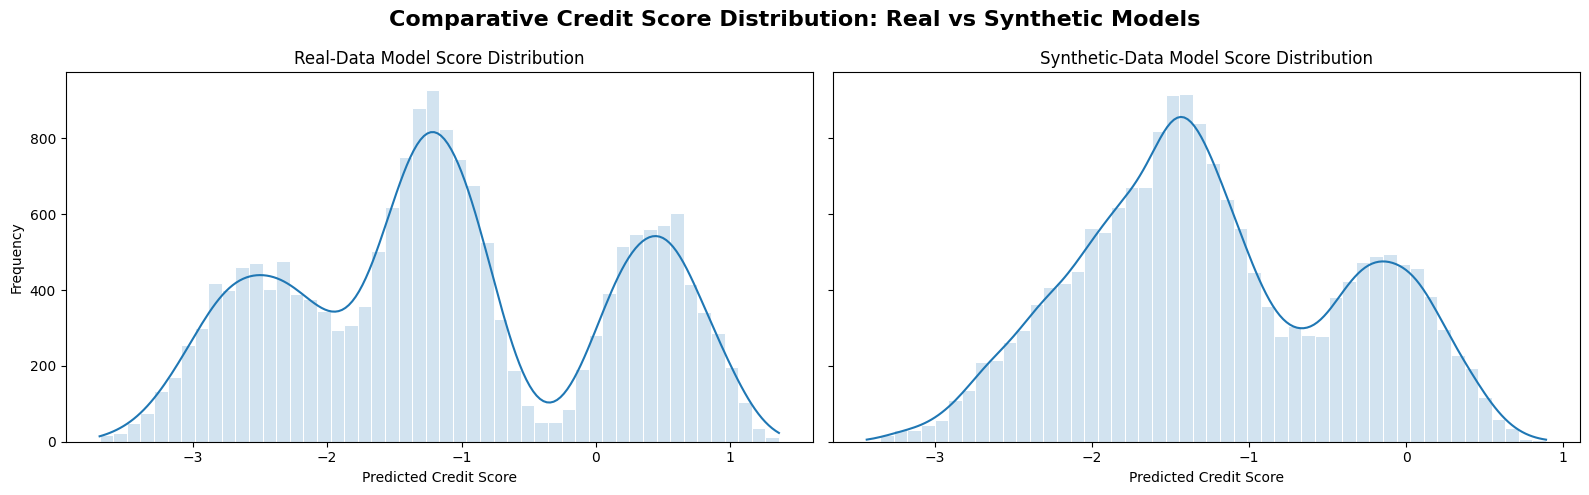

In [156]:
def plot_comparative_credit_score_distribution(
    real_scores,
    synth_scores,
    bins=50,
    kde=True,
    title='Comparative Credit Score Distribution: Real vs Synthetic Models'
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    sns.histplot(
        real_scores,
        bins=bins,
        kde=kde,
        color='#1F77B4',
        edgecolor='white',
        alpha=0.2,
        ax=axes[0]
    )
    axes[0].set_title('Real-Data Model Score Distribution')
    axes[0].set_xlabel('Predicted Credit Score')
    axes[0].set_ylabel('Frequency')

    sns.histplot(
        synth_scores,
        bins=bins,
        kde=kde,
        color='#1F77B4',
        edgecolor='white',
        alpha=0.2,
        ax=axes[1]
    )
    axes[1].set_title('Synthetic-Data Model Score Distribution')
    axes[1].set_xlabel('Predicted Credit Score')
    axes[1].set_ylabel('Frequency')

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_comparative_credit_score_distribution(test_real_data_scores, test_synth_data_scores)

In [126]:
def get_metrics_df(y_true, y_real_pred, y_synth_pred):
    metrics = {
        'Model': ['Real Data Model', 'Synthetic Data Model'],
        'Accuracy': [
            accuracy_score(y_true, y_real_pred),
            accuracy_score(y_true, y_synth_pred)
        ],
        'Precision': [
            precision_score(y_true, y_real_pred, average='weighted'),
            precision_score(y_true, y_synth_pred, average='weighted')
        ],
        'Recall': [
            recall_score(y_true, y_real_pred, average='weighted'),
            recall_score(y_true, y_synth_pred, average='weighted')
        ],
        'F1-Score': [
            f1_score(y_true, y_real_pred, average='weighted'),
            f1_score(y_true, y_synth_pred, average='weighted')
        ]
    }
    return pd.DataFrame(metrics)

metrics_df = get_metrics_df(y_real_test, real_data_classifications, test_synth_data_classifications)

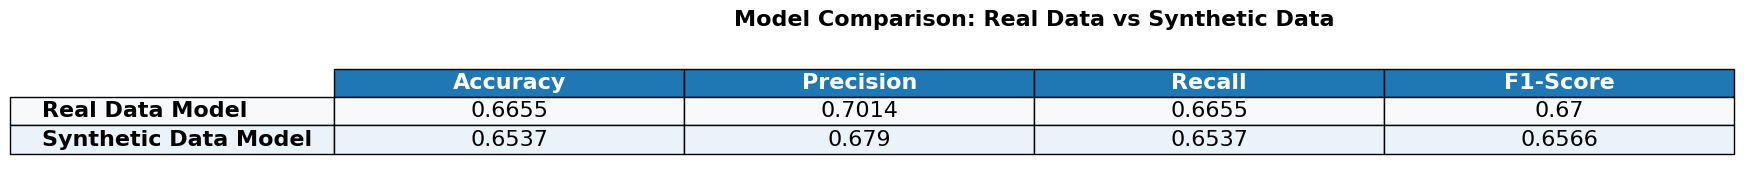

In [136]:
def plot_comparison_table(metrics_df, title='Model Comparison: Real Data vs Synthetic Data'):
    display_df = metrics_df.copy().round(4).set_index('Model')

    fig, ax = plt.subplots(figsize=(18, 2))
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=12)

    table = ax.table(
        cellText=display_df.values,
        rowLabels=display_df.index,
        colLabels=display_df.columns,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(16)
    table.scale(1.2, 1.9)

    for j in range(len(display_df.columns)):
        table[(0, j)].set_facecolor('#1F77B4')
        table[(0, j)].set_text_props(color='white', weight='bold')

    for i in range(1, len(display_df.index) + 1):
        bg = '#F7F9FB' if i % 2 else '#EAF2FA'
        table[(i, -1)].set_text_props(weight='bold')
        table[(i, -1)].set_facecolor(bg)
        for j in range(len(display_df.columns)):
            table[(i, j)].set_facecolor(bg)

    plt.tight_layout()
    plt.show()

plot_comparison_table(metrics_df)

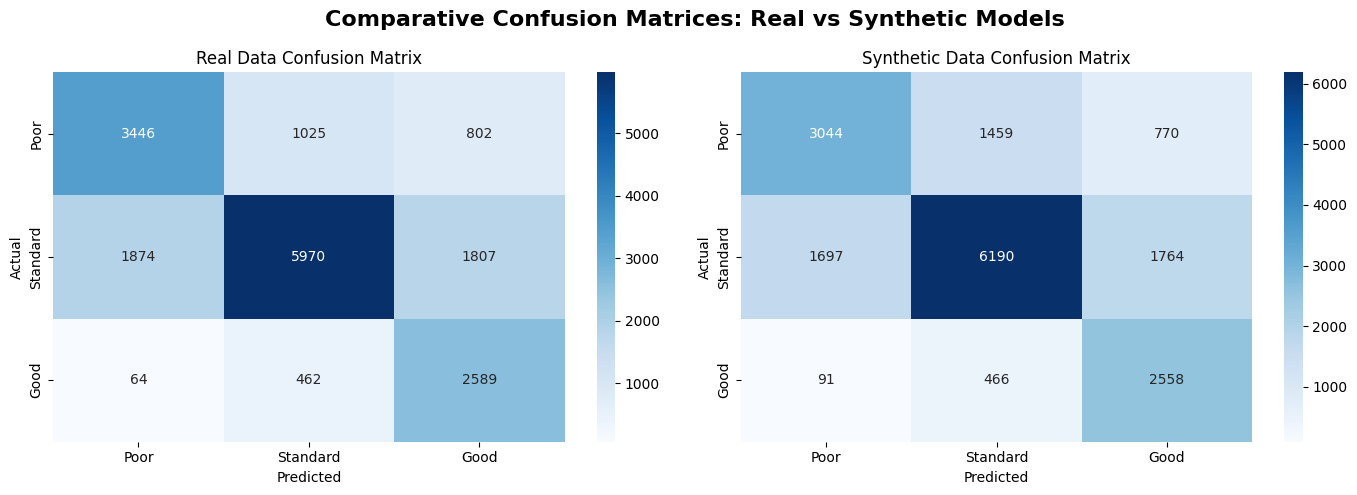

In [138]:
def plot_comparative_confusion_matrices(
    y_true,
    y_pred_real,
    y_pred_synth,
    labels=None,
    normalize=False,
    cmap='Blues'
):
    cm_real = confusion_matrix(y_true, y_pred_real, labels=labels)
    cm_synth = confusion_matrix(y_true, y_pred_synth, labels=labels)

    if normalize:
        cm_real_plot = cm_real.astype(float) / cm_real.sum(axis=1, keepdims=True)
        cm_synth_plot = cm_synth.astype(float) / cm_synth.sum(axis=1, keepdims=True)
        fmt = '.2f'
    else:
        cm_real_plot = cm_real
        cm_synth_plot = cm_synth
        fmt = 'd'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm_real_plot, annot=True, fmt=fmt, cmap=cmap,
        xticklabels=labels, yticklabels=labels, ax=axes[0]
    )
    axes[0].set_title(f"Real Data Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(
        cm_synth_plot, annot=True, fmt=fmt, cmap=cmap,
        xticklabels=labels, yticklabels=labels, ax=axes[1]
    )
    axes[1].set_title(f"Synthetic Data Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    fig.suptitle("Comparative Confusion Matrices: Real vs Synthetic Models", fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_comparative_confusion_matrices(
    y_true=y_real_test,
    y_pred_real=real_data_classifications,
    y_pred_synth=test_synth_data_classifications,
    labels=score_labels,
    normalize=False
)

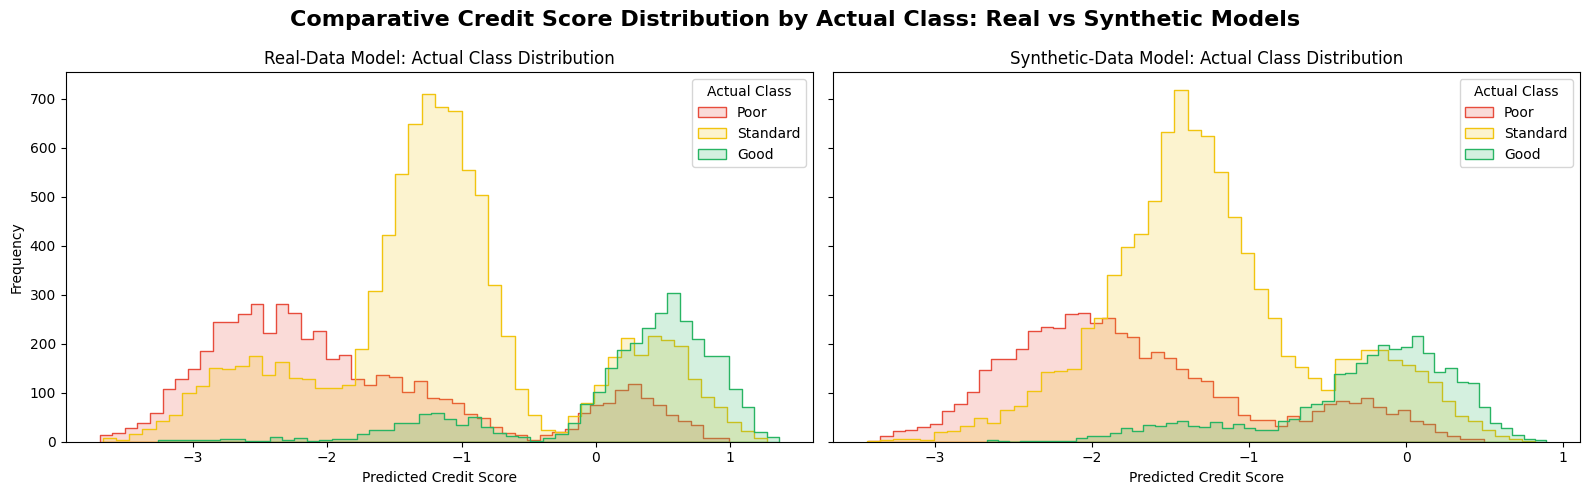

In [155]:
def plot_comparative_credit_score_distribution_by_actual_class(
    y_true,
    real_scores,
    synth_scores,
    color_map,
    label_order=None,
    bins=50,
):
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    y_true_arr = pd.Series(y_true).values

    for label in label_order:
        mask = (y_true_arr == label)

        sns.histplot(
            real_scores[mask],
            bins=bins,
            stat='count',
            element='step',
            fill=True,
            alpha=0.2,
            color=color_map.get(label, None),
            label=label,
            ax=ax_left
        )

        sns.histplot(
            synth_scores[mask],
            bins=bins,
            stat='count',
            element='step',
            fill=True,
            alpha=0.2,
            color=color_map.get(label, None),
            label=label,
            ax=ax_right
        )

    ax_left.set_title('Real-Data Model: Actual Class Distribution')
    ax_left.set_xlabel('Predicted Credit Score')
    ax_left.set_ylabel('Frequency')
    ax_left.legend(title='Actual Class')

    ax_right.set_title('Synthetic-Data Model: Actual Class Distribution')
    ax_right.set_xlabel('Predicted Credit Score')
    ax_right.set_ylabel('Frequency')
    ax_right.legend(title='Actual Class')

    plt.suptitle('Comparative Credit Score Distribution by Actual Class: Real vs Synthetic Models', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_comparative_credit_score_distribution_by_actual_class(
    y_true=y_real_test,
    real_scores=test_real_data_scores,
    synth_scores=test_synth_data_scores,
    label_order=score_labels,
    color_map={
        'Good': '#28B463',
        'Standard': '#F1C40F',
        'Poor': '#E74C3C'
    }
)
